In [1]:
import numpy as np
from guarnatee_lib.wiggle import Wiggle
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from scipy import signal, stats
from numba import njit, prange

In [3]:
@njit(parallel=True, cache=True)
def _compute_rolling_stats(windows):
    """
    Numba optimized core
    """
    n_windows, window_size = windows.shape
    medians = np.empty(n_windows, dtype=np.float64)
    mads = np.empty(n_windows, dtype=np.float64)
    
    for i in prange(n_windows):
        row = windows[i]
        med = np.median(row)
        abs_diffs = np.abs(row - med)
        mad = np.median(abs_diffs)
        medians[i] = med
        mads[i] = mad
        
    return medians, mads

def rolling_robust_mad(
    arr: np.ndarray, 
    window_size: int = 21, 
    sigma_cut: float = 3.0, 
    k_factor: float = 1.4826,
    center: bool = True
):
    """
    Calculates Rolling Robust MA with option to Center the window.
    
    Args:
    - center: If True, window is centered (no lag). If False, window is causal (lagged).
    """
    n = len(arr)
    if n < window_size:
        raise ValueError("Data length must be larger than window size.")

    # --- PADDING LOGIC HERE ---
    if center:
        # Pad both sides to center the window on the current point
        pad_before = (window_size - 1) // 2
        pad_after = window_size // 2
        padded_arr = np.pad(arr, (pad_before, pad_after), mode='edge')
    else:
        # Pad only the beginning (Causal/Real-time mode)
        pad_qty = window_size - 1
        padded_arr = np.pad(arr, (pad_qty, 0), mode='edge')

    # Create views and compute
    windows = sliding_window_view(padded_arr, window_shape=window_size)
    medians, mads = _compute_rolling_stats(windows)

    # Calculate Bounds
    deviation = mads * k_factor * sigma_cut
    upper_bound = medians + deviation
    lower_bound = medians - deviation

    # Identify Outliers
    outlier_mask = (arr > upper_bound) | (arr < lower_bound)
    outlier_indices = np.where(outlier_mask)[0]

    return {
        "upper_bound": upper_bound,
        "lower_bound": lower_bound,
        "outlier_indices": outlier_indices,
        "medians": medians,
        "mads": mads
    }

In [4]:
def parse_wig(in_path):
    wig_obj = Wiggle(in_path)
    wig_df = wig_obj.signals["NZ_CP033110.1"]
    return wig_df
#term_raw = "/home/muhoss/analysis_2022/OD_2.0_Term-Seq_Rep_1_forward.wig"
#tex_pos_raw = "/home/muhoss/analysis_2022/OD_2.0_TEX_pos_Rep_1_forward.wig"
#tex_pos_raw = "/home/muhoss/analysis_2022/20210828_OD_0.2_TEX_pos_Rep_1_forward.wig"
#tex_neg_raw = "/home/muhoss/analysis_2022/OD_2.0_TEX_neg_Rep_1_forward.wig"
#term_raw_arr = parse_wig(term_raw)
#tex_pos_raw_arr = parse_wig(tex_pos_raw)
ab_p1f = "/home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p1_forward.wig"
ab_p2f = "/home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p2_forward.wig"
ab_p1r = "/home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p1_reverse.wig"
ab_p2r = "/home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p2_reverse.wig"
ab_p1f_arr = parse_wig(ab_p1f)
ab_p2f_arr = parse_wig(ab_p2f)
ab_p1r_arr = parse_wig(ab_p1r)
ab_p2r_arr = parse_wig(ab_p2r)

Parsing /home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p1_forward.wig
==> Loading file: A_baumannii_ATCC_17978_OD_0.2_rep1_p1_forward.wig
===> Trying to get sequence ID length for: NZ_CP033110.1
====> Size retrieved for NZ_CP033110.1 is: 3902037
===> Trying to get sequence ID length for: NZ_CP033111.1
====> Size retrieved for NZ_CP033111.1 is: 148955
===> Parsed condition: A_baumannii_ATCC_17978_OD_0.2_rep1_p1_forward
     + Sequence IDs included:
     └── NZ_CP033110.1
     └── NZ_CP033111.1
Parsing /home/muhoss/git_repos/GuaRNAtee/inputs/wigs/A_baumannii_ATCC_17978_OD_0.2_rep1_p2_forward.wig
==> Loading file: A_baumannii_ATCC_17978_OD_0.2_rep1_p2_forward.wig
===> Trying to get sequence ID length for: NZ_CP033110.1
====> Size retrieved for NZ_CP033110.1 is: 3902037
===> Trying to get sequence ID length for: NZ_CP033111.1
====> Size retrieved for NZ_CP033111.1 is: 148955
===> Parsed condition: A_baumannii_ATCC_17978_OD_0.2_rep1_p2_forward
     + Sequenc

In [5]:
pos0 = (2815314, 2815572) #ab_p1f_arr ssrs
pos1 = (938471, 938600) #ab_p2r_arr
pos2 = (936680, 936990) #ab_p1f_arr
pos3 = (934072, 934575) #ab_p2r_arr 
selected_pos = pos0
selected_arr5 = ab_p1f_arr
selected_arr3 = ab_p2f_arr
polyorder = 1
delta = 0.1
smooth_win5 = 7
smooth_win3 = 31

In [24]:
# 5' end full
raw_deriv5 = np.diff(selected_arr5)
smooth_deriv5 = signal.savgol_filter(selected_arr5, window_length=smooth_win5, polyorder=polyorder, deriv=1, delta=delta)
results_dict5 = rolling_robust_mad(smooth_deriv5, window_size=smooth_win5*3, sigma_cut=3)
#  5' end slice
raw5_pos = selected_arr5[selected_pos[0]:selected_pos[1]]
raw_deriv5_pos = raw_deriv5[selected_pos[0]:selected_pos[1]]
smooth_deriv5_pos = smooth_deriv5[selected_pos[0]:selected_pos[1]]
threshold5_pos = results_dict5["upper_bound"][selected_pos[0]:selected_pos[1]]
smooth_deriv5_max_idx = np.argmax(smooth_deriv5_pos)
smooth_deriv5_max = np. max(smooth_deriv5_pos)

In [30]:
# 3' end full
raw_deriv3 = np.diff(selected_arr3)
smooth_deriv3 = signal.savgol_filter(selected_arr3, window_length=smooth_win3, polyorder=polyorder, deriv=1, delta=delta)
results_dict3 = rolling_robust_mad(smooth_deriv3, window_size=smooth_win3*3, sigma_cut=3)
#  3' end slice
raw3_pos = selected_arr3[selected_pos[0]:selected_pos[1]]
raw_deriv3_pos = raw_deriv3[selected_pos[0]:selected_pos[1]] * -1
smooth_deriv3_pos = smooth_deriv3[selected_pos[0]:selected_pos[1]] * -1
threshold3_pos = results_dict3["upper_bound"][selected_pos[0]:selected_pos[1]]
smooth_deriv3_max_idx = np.argmax(smooth_deriv3_pos)
smooth_deriv3_max = np.max(smooth_deriv3_pos)


In [102]:
sigs_dict5 = {
    "a) raw coverage": raw5_pos,
    "b) 1st derivative of raw coverage" : raw_deriv5_pos,
    "smooth_deriv": smooth_deriv5_pos,
    "threshold": threshold3_pos
}
sigs_dict3 = {
    "a) raw coverage": raw3_pos,
    "b) 1st derivative of raw coverage" : raw_deriv3_pos,
    "smooth_deriv": smooth_deriv3_pos,
    "threshold": threshold3_pos
}
#plot(sigs_dict5, sigs_dict3, vline_x=[smooth_deriv5_max, smooth_deriv3_max])

In [103]:
def plot(data_dict, main_title="Signal Analysis", x_indices=None, label="Trigger"):
    """
    Plots signals with a minimalist style, BUT keeps the legend box.
    """
    
    keys_to_plot = [k for k in data_dict.keys() if k != "threshold"]
    n_rows = len(keys_to_plot)
    
    fig, ax = plt.subplots(nrows=n_rows, ncols=1, figsize=(9, 3 * n_rows), squeeze=False)
    
    plt.suptitle(main_title, fontsize=16, y=1.02)

    # Normalize x_indices
    if x_indices is None:
        indices = []
    elif isinstance(x_indices, (int, float, np.integer)):
        indices = [int(x_indices)]
    elif isinstance(x_indices, list):
        indices = x_indices
    else:
        indices = list(x_indices)

    for i, key in enumerate(keys_to_plot):
        current_ax = ax[i, 0]
        signal_data = data_dict[key]
        
        # --- 1. Plot Main Signal ---
        current_ax.plot(signal_data, color='tab:blue', label=key if key != "smooth_deriv" else "SavGol Signal")
        
        # Handle Threshold
        if key == "smooth_deriv" and "threshold" in data_dict:
            current_ax.plot(data_dict["threshold"], color='red', linestyle='--', label="threshold")
            
            # --- RESTORED LEGEND BOX HERE ---
            # frameon=True is the default, so you can just call legend()
            # framealpha=1 ensures the box is opaque (hiding lines behind it)
            current_ax.legend(loc="lower right", frameon=True, framealpha=1.0, edgecolor='black')

        # --- 2. Styling ---
        # Remove the plot border
        current_ax.set_frame_on(False)
        
        # Remove X-axis ticks/labels
        current_ax.get_xaxis().set_visible(False)
        
        # Keep grid for Y-axis reference
        current_ax.grid(True, axis='y', alpha=0.3)

        # --- 3. Triggers ---
        for idx in indices:
            idx = int(idx)
            if not (0 <= idx < len(signal_data)): continue 

            # Vertical Line
            current_ax.axvline(x=idx, color='red', linestyle='-', linewidth=1, alpha=0.5)

            # Conditional Dot
            if key == "smooth_deriv":
                y_val = signal_data[idx]
                current_ax.plot(idx, y_val, 'ro', markersize=8, zorder=5)
                current_ax.text(x=idx, y=y_val, s=f"  {label}", 
                                color='red', fontsize=10, fontweight='bold', 
                                va='bottom')

        current_ax.set_title(key if key != "smooth_deriv" else "c) SavGol smoothed 1st derivative with predicted point", loc='left')

    plt.tight_layout()
    plt.savefig(f"{'dRNA_sig' if '5' in label else 'Term_sig'}.png", bbox_inches='tight')
    plt.show()
    

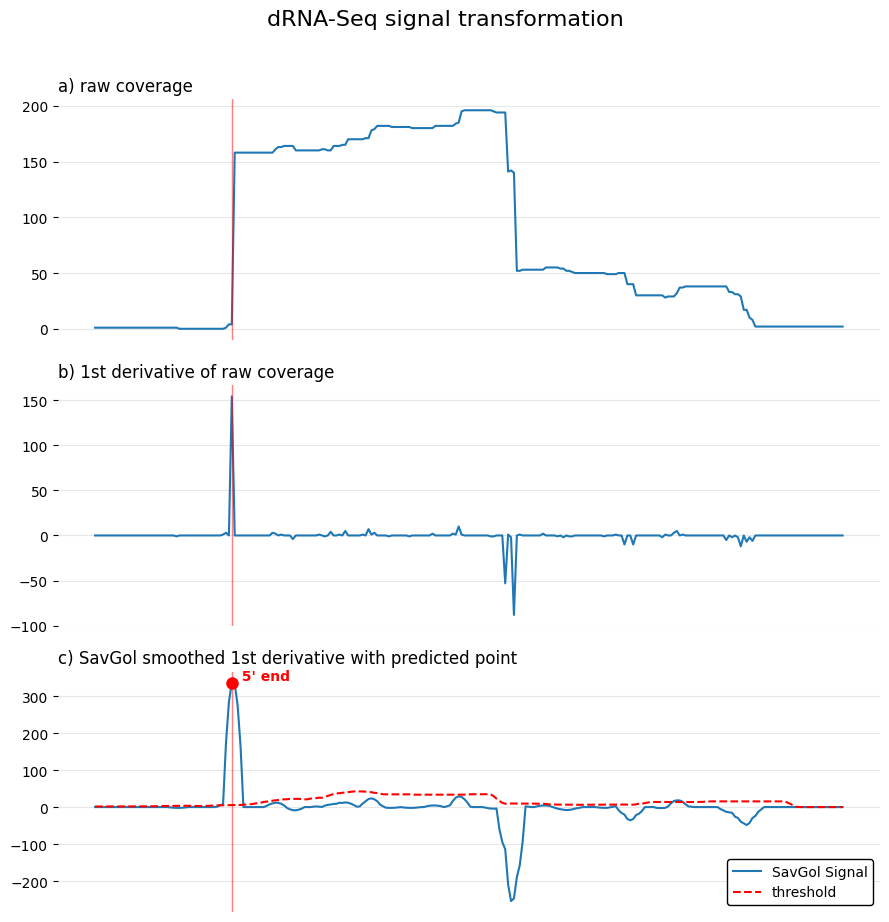

In [104]:
plot(sigs_dict5, main_title="dRNA-Seq signal transformation", x_indices=smooth_deriv5_max_idx, label="5' end")


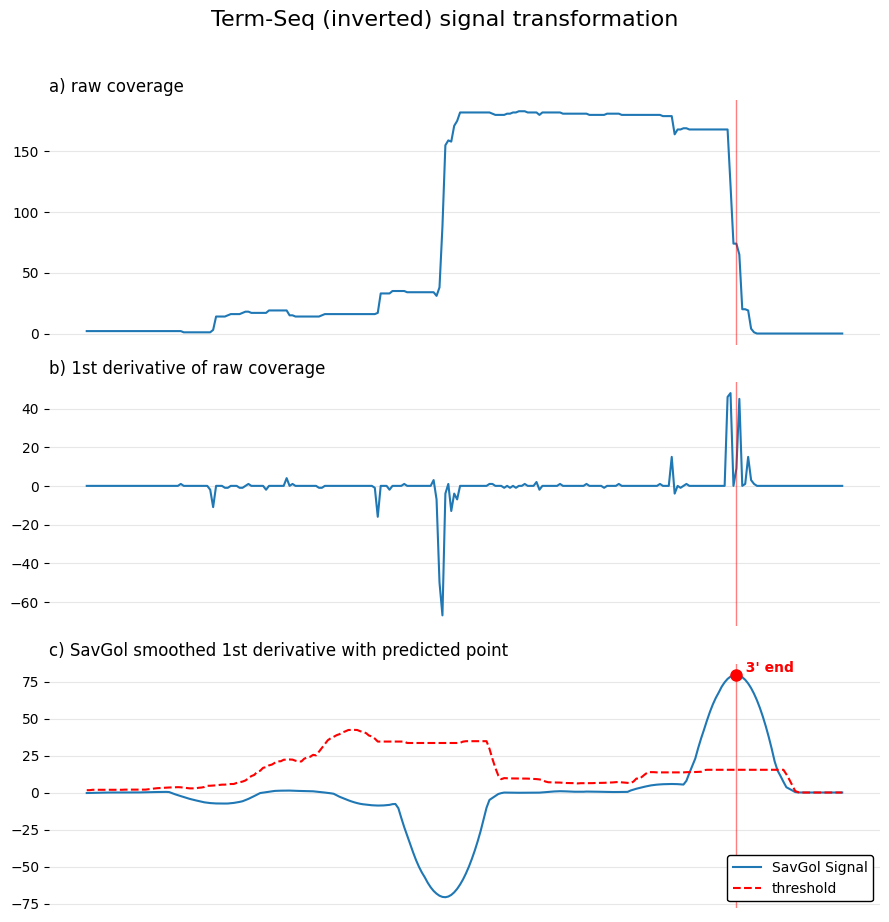

In [105]:
plot(sigs_dict3, main_title="Term-Seq (inverted) signal transformation", x_indices=smooth_deriv3_max_idx, label="3' end")